In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (5)\online_retail.csv", encoding='ISO-8859-1')
df.head()
df.shape
df.info()

In [ ]:
# Data Cleaning :
# Remove rows where CustomerID is missing
# Reason: We cannot identify or group customers without an ID
df = df.dropna(subset=['CustomerID'])

# Remove unnecessary 'index' column
# Reason: This column has no analytical value (just extra baggage)
df = df.drop(columns=['index'])

# Check new shape after cleaning
# Reason: To confirm rows reduced and column count is correct
df.shape

In [28]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [32]:
# What is the recency of the customers?
# Step 1: Find the latest date in dataset
# Reason: This will act as our "current date"
reference_date = df['InvoiceDate'].max()

# Step 2: Add 1 day
# Reason: Avoid recency = 0 for latest customer
reference_date = reference_date + pd.Timedelta(days=1)

# Step 3: Group by CustomerID and find last purchase date
# Reason: We need each customer's most recent transaction
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()

# Step 4: Calculate Recency
# Reason: Difference between reference date and last purchase
recency = (reference_date - last_purchase).dt.days

# Convert to DataFrame
# Reason: Easier to work with later
recency = recency.reset_index()
recency.columns = ['CustomerID', 'Recency']

recency.head(10)

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310
5,12352.0,36
6,12353.0,204
7,12354.0,232
8,12355.0,214
9,12356.0,23


In [40]:
# How frequent do the customers buy the products?
# Calculate frequency (number of transactions per customer)
# Reason: Measures how often a customer purchases
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Convert to DataFrame
# Reason: Makes it easier to merge later
frequency = frequency.reset_index()
frequency.columns = ['CustomerID', 'Frequency']
frequency.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [42]:
# Monetary of the customers. Monetary = Total amount spent by each customer
# Step 1: Create TotalPrice column
# Reason: Each row = Quantity × UnitPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Step 2: Calculate total spend per customer
# Reason: Sum of all purchases made by each customer
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

# Convert to DataFrame
# Reason: Easier to merge with R and F later
monetary = monetary.reset_index()
monetary.columns = ['CustomerID', 'Monetary']

# Preview
monetary.head()

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [44]:
# Merge Recency and Frequency
# Reason: Combine both metrics based on CustomerID
rfm = recency.merge(frequency, on='CustomerID')

# Merge with Monetary
# Reason: Add spending data to same table
rfm = rfm.merge(monetary, on='CustomerID')

# Preview final RFM table
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [54]:
# Remove customers with Monetary = 0
# Reason: These are likely returns or invalid transactions
rfm = rfm[rfm['Monetary'] > 0]

rfm.shape
rfm.head()

,CustomerID,Recency,Frequency,Monetary
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,11,1545.41


In [60]:
from sklearn.preprocessing import StandardScaler

# Select only RFM features (exclude CustomerID)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Apply scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_features.head()

pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary']).head()

,Recency,Frequency,Monetary
0,-0.891260,0.200814,0.288849
1,-0.154795,-0.118900,-0.015280
2,-0.719755,-0.438615,-0.020084
3,2.216019,-0.438615,-0.192332
4,-0.548249,0.627100,-0.045760


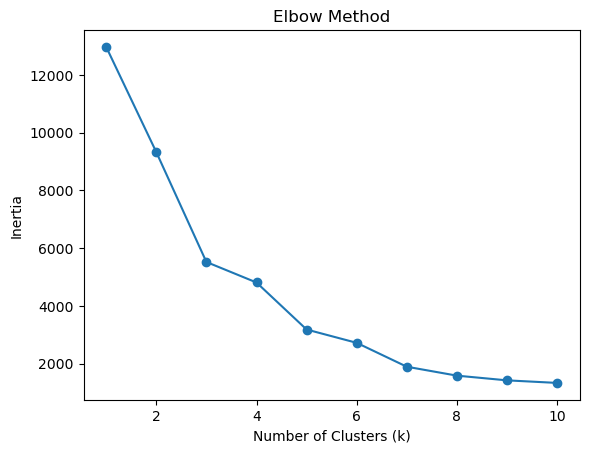

In [66]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Finding optimal number of clusters using Elbow Method
inertia = []

# Trying different k values (1 to 10)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the graph
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [68]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,1
3,12349.0,19,1,1757.55,1
4,12350.0,310,1,334.40,0
5,12352.0,36,11,1545.41,1


In [70]:
# Group by cluster and find average RFM values
# Reason: To understand behavior of each cluster
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15366.671309,243.561746,1.869081,488.596872
1,15276.827019,39.750932,5.595031,1807.348271
2,15166.666667,1.333333,213.666667,67328.500000
3,15158.090909,6.681818,65.454545,80246.781364


In [82]:
# Map cluster numbers to meaningful names
cluster_names = {
    0: 'Lost Customers',
    1: 'Regular Customers',
    2: 'VIP Customers',
    3: 'High-Value Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
1,12347.0,2,7,4310.00,1,Regular Customers
2,12348.0,75,4,1797.24,1,Regular Customers
3,12349.0,19,1,1757.55,1,Regular Customers
4,12350.0,310,1,334.40,0,Lost Customers
5,12352.0,36,11,1545.41,1,Regular Customers
6,12353.0,204,1,89.00,0,Lost Customers
7,12354.0,232,1,1079.40,0,Lost Customers
8,12355.0,214,1,459.40,0,Lost Customers
9,12356.0,23,3,2811.43,1,Regular Customers
10,12357.0,33,1,6207.67,1,Regular Customers


In [84]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    1077
1    3220
2       3
3      22
Name: count, dtype: int64

In [93]:
# Sort high-value customers by spending (highest first)
high_value_customers.sort_values(by='Monetary', ascending=False)

# Get only Customer IDs of top customers
high_value_customers['CustomerID']

55      12415.0
330     12748.0
487     12971.0
568     13089.0
803     13408.0
1005    13694.0
1078    13798.0
1300    14096.0
1345    14156.0
1447    14298.0
1674    14606.0
1703    14646.0
1895    14911.0
1999    15061.0
2192    15311.0
2537    15769.0
2708    16013.0
2722    16029.0
3014    16422.0
3202    16684.0
3758    17450.0
3801    17511.0
4042    17841.0
4125    17949.0
4233    18102.0
Name: CustomerID, dtype: float64

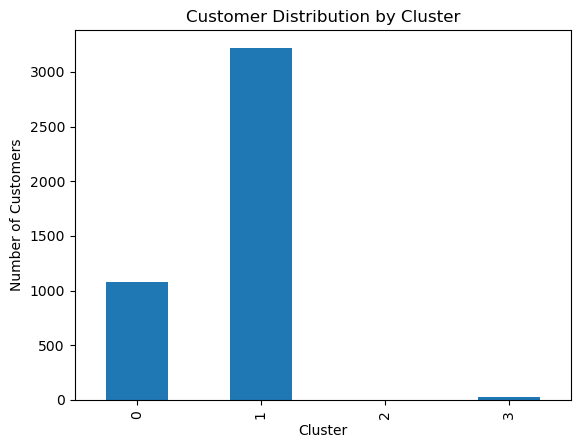

In [95]:
# Count customers per cluster
# Reason: To see how customers are distributed
cluster_counts = rfm['Cluster'].value_counts().sort_index()

# Plot bar chart
cluster_counts.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')
plt.show()


# 1. Customer Distribution (first graph)

#  Cluster 1 has the MOST customers (~3200+)
#  Cluster 0 → second largest (~1000+)
#  Cluster 3 → very few (~20)
#  Cluster 2 → almost none (~3)

#  Meaning:
# Majority = normal customers
# Tiny minority = elite customers


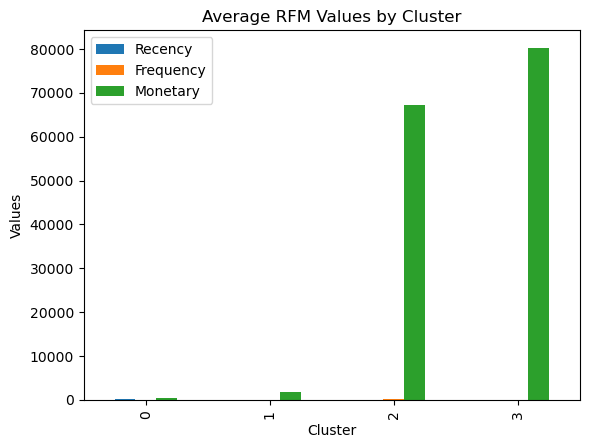

In [97]:
# Calculate average RFM per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Plot
cluster_summary.plot(kind='bar')

plt.title('Average RFM Values by Cluster')
plt.ylabel('Values')
plt.show()

# 2. Revenue Contribution (third graph)

#  Cluster 1 generates the MOST revenue
#  Cluster 3 → second highest
#  Cluster 0 → low
#  Cluster 2 → very low (because only 3 customers)

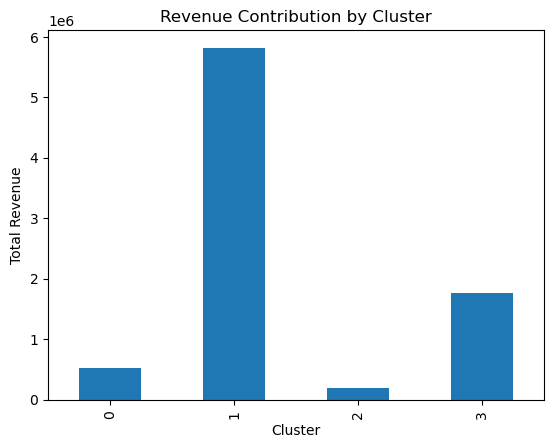

In [99]:
# Total revenue per cluster
revenue = rfm.groupby('Cluster')['Monetary'].sum()

# Plot
revenue.plot(kind='bar')

plt.title('Revenue Contribution by Cluster')
plt.ylabel('Total Revenue')
plt.show()

In [ ]:
# While high-value customers (Cluster 3) have the highest individual spending,
# the majority of revenue is driven by regular customers (Cluster 1) due to their large 
# population.

In [103]:
rfm.to_csv("rfm_segmentation.csv", index=False)